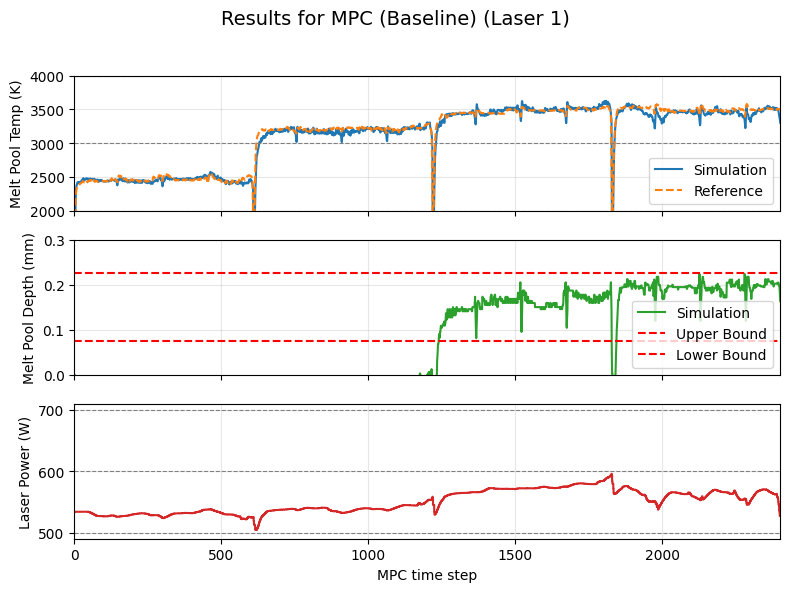

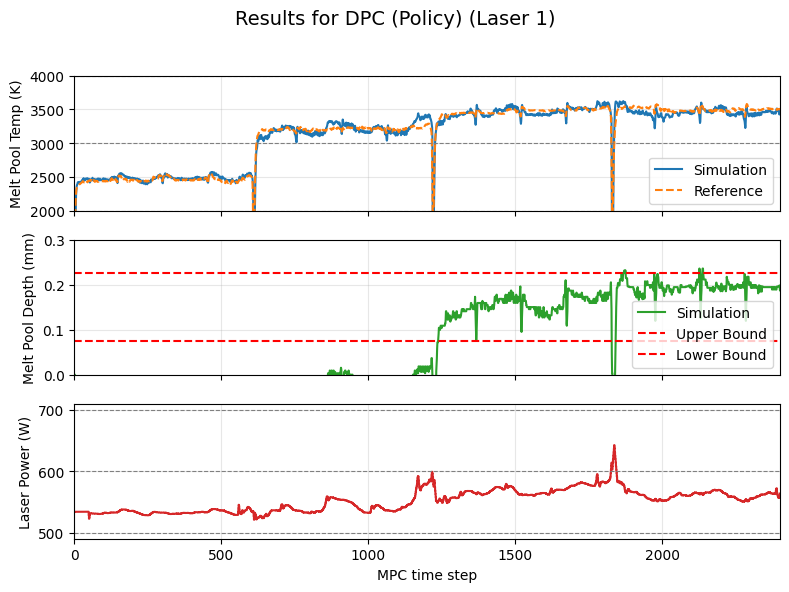

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_individual_results(csv_path_or_dir, label, laser_num=1, N_step=None):
    """
    각 데이터(MPC 또는 DPC)를 받아서 3x1 서브플롯으로 그리는 함수
    """
    try:
        # 1. 데이터 로드 (파일 경로 형태인지 디렉토리 형태인지 판단)
        if os.path.isdir(csv_path_or_dir):
            # DPC 케이스: 여러 csv 파일이 모여있는 디렉토리
            x = pd.read_csv(os.path.join(csv_path_or_dir, f"x_outputs_laser_{laser_num}.csv")).values
            u = pd.read_csv(os.path.join(csv_path_or_dir, f"u_outputs_laser_{laser_num}.csv")).values
            ref = pd.read_csv(os.path.join(csv_path_or_dir, f"ref_laser_{laser_num}.csv")).values.flatten()
        else:
            # MPC 케이스: 하나의 통합 csv 파일
            df = pd.read_csv(csv_path_or_dir)
            # CSV 컬럼명에 따라 수정이 필요할 수 있습니다 (예: 'temp', 'depth', 'power' 등)
            x = df[['temp', 'depth']].values if 'temp' in df.columns else df.iloc[:, :2].values
            u = df['LP'].values if 'LP' in df.columns else df.iloc[:, 2].values
            ref = df['ref'].values if 'ref' in df.columns else df.iloc[:, 3].values

        # 2. 데이터 길이 맞추기
        if N_step is None:
            N_step = min(len(x), len(u), len(ref))

        # 3. 플롯 생성
        fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
        plt.suptitle(f"Results for {label} (Laser {laser_num})", fontsize=14)

        # --- 1. Melt Pool Temperature ---
        ax1 = axes[0]
        ax1.plot(x[:N_step, 0], label="Simulation", color='tab:blue')
        ax1.plot(ref[:N_step], label="Reference", color='tab:orange', linestyle='--')
        for yline in [2000, 3000, 4000]:
            ax1.axhline(y=yline, color='gray', linestyle='--', linewidth=0.8)
        ax1.set_ylabel("Melt Pool Temp (K)")
        ax1.set_ylim(2000, 4000)
        ax1.set_xlim(0, 2400)
        #ax1.set_xlim(2400, 5000)
        ax1.legend(loc='lower right')
        ax1.grid(True, alpha=0.3)

        # --- 2. Melt Pool Depth ---
        ax2 = axes[1]
        ax2.plot(x[:N_step, 1], label="Simulation", color='tab:green')
        ax2.axhline(y=0.225, linestyle='--', color='r', label="Upper Bound")
        ax2.axhline(y=0.075, linestyle='--', color='r', label="Lower Bound")
        ax2.set_ylabel("Melt Pool Depth (mm)")
        ax2.set_ylim(-0.0, 0.3) # 데이터에 맞춰 조정 가능
        ax2.legend(loc='lower right')
        ax2.grid(True, alpha=0.3)

        # --- 3. Laser Power (Control Input) ---
        ax3 = axes[2]
        ax3.step(range(N_step), u[:N_step], label="Control Input", color='tab:red')
        for yline in [500, 600, 700]:
            ax3.axhline(y=yline, color='gray', linestyle='--', linewidth=0.8)
        ax3.set_xlabel("MPC time step")
        ax3.set_ylabel("Laser Power (W)")
        #ax3.set_ylim(450, 750)
        ax3.grid(True, alpha=0.3)

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

    except Exception as e:
        print(f"❌ Failed to plot for {label}: {e}")

if __name__ == "__main__":
    # 경로 설정
    mpc_csv = "/home/ftk3187/github/DPC_research/MPC_research_submodule/DED/depth_constrained_rmpc_JMD/profile_1_RMPC_w_depth_control.csv"
    dpc_dir = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/simulation/policy_roll_epoch0199.pth_clamped(1)"

    # 1. MPC 결과 플롯
    plot_individual_results(mpc_csv, label="MPC (Baseline)")

    # 2. DPC 결과 플롯
    plot_individual_results(dpc_dir, label="DPC (Policy)")

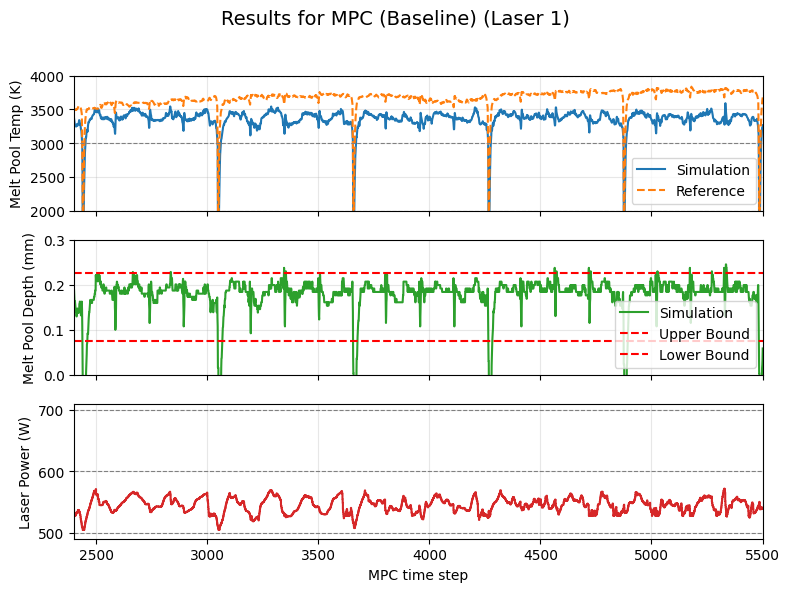

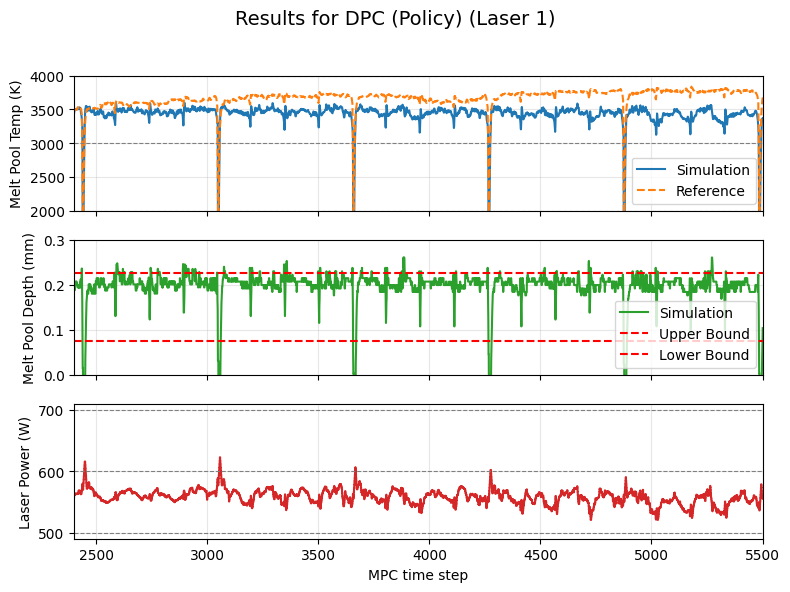

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_individual_results(csv_path_or_dir, label, laser_num=1, N_step=None):
    """
    각 데이터(MPC 또는 DPC)를 받아서 3x1 서브플롯으로 그리는 함수
    """
    try:
        # 1. 데이터 로드 (파일 경로 형태인지 디렉토리 형태인지 판단)
        if os.path.isdir(csv_path_or_dir):
            # DPC 케이스: 여러 csv 파일이 모여있는 디렉토리
            x = pd.read_csv(os.path.join(csv_path_or_dir, f"x_outputs_laser_{laser_num}.csv")).values
            u = pd.read_csv(os.path.join(csv_path_or_dir, f"u_outputs_laser_{laser_num}.csv")).values
            ref = pd.read_csv(os.path.join(csv_path_or_dir, f"ref_laser_{laser_num}.csv")).values.flatten()
        else:
            # MPC 케이스: 하나의 통합 csv 파일
            df = pd.read_csv(csv_path_or_dir)
            # CSV 컬럼명에 따라 수정이 필요할 수 있습니다 (예: 'temp', 'depth', 'power' 등)
            x = df[['temp', 'depth']].values if 'temp' in df.columns else df.iloc[:, :2].values
            u = df['LP'].values if 'LP' in df.columns else df.iloc[:, 2].values
            ref = df['ref'].values if 'ref' in df.columns else df.iloc[:, 3].values

        # 2. 데이터 길이 맞추기
        if N_step is None:
            N_step = min(len(x), len(u), len(ref))

        # 3. 플롯 생성
        fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
        plt.suptitle(f"Results for {label} (Laser {laser_num})", fontsize=14)

        # --- 1. Melt Pool Temperature ---
        ax1 = axes[0]
        ax1.plot(x[:N_step, 0], label="Simulation", color='tab:blue')
        ax1.plot(ref[:N_step], label="Reference", color='tab:orange', linestyle='--')
        for yline in [2000, 3000, 4000]:
            ax1.axhline(y=yline, color='gray', linestyle='--', linewidth=0.8)
        ax1.set_ylabel("Melt Pool Temp (K)")
        ax1.set_ylim(2000, 4000)
        #ax1.set_xlim(0, 2400)
        ax1.set_xlim(2400, 5500)
        ax1.legend(loc='lower right')
        ax1.grid(True, alpha=0.3)

        # --- 2. Melt Pool Depth ---
        ax2 = axes[1]
        ax2.plot(x[:N_step, 1], label="Simulation", color='tab:green')
        ax2.axhline(y=0.225, linestyle='--', color='r', label="Upper Bound")
        ax2.axhline(y=0.075, linestyle='--', color='r', label="Lower Bound")
        ax2.set_ylabel("Melt Pool Depth (mm)")
        ax2.set_ylim(-0.0, 0.3) # 데이터에 맞춰 조정 가능
        ax2.legend(loc='lower right')
        ax2.grid(True, alpha=0.3)

        # --- 3. Laser Power (Control Input) ---
        ax3 = axes[2]
        ax3.step(range(N_step), u[:N_step], label="Control Input", color='tab:red')
        for yline in [500, 600, 700]:
            ax3.axhline(y=yline, color='gray', linestyle='--', linewidth=0.8)
        ax3.set_xlabel("MPC time step")
        ax3.set_ylabel("Laser Power (W)")
        #ax3.set_ylim(450, 750)
        ax3.grid(True, alpha=0.3)

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

    except Exception as e:
        print(f"❌ Failed to plot for {label}: {e}")

if __name__ == "__main__":
    # 경로 설정
    mpc_csv = "/home/ftk3187/github/DPC_research/MPC_research_submodule/DED/depth_constrained_rmpc_JMD/profile_1_RMPC_w_depth_control.csv"
    dpc_dir = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved_draft_88/or_3L_1024H_s1_c10_ep500_roll50_m102400_case_88aug_lower_layer_constraint_off_uconst(10)_trackingboostatfirstlayers(10)_init_layerchangeonlylow_scheduleroff/simulation/policy_roll_epoch0199.pth_clamped(1)"

    # 1. MPC 결과 플롯
    plot_individual_results(mpc_csv, label="MPC (Baseline)")

    # 2. DPC 결과 플롯
    plot_individual_results(dpc_dir, label="DPC (Policy)")